In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

In [8]:
no_dummies = pd.read_csv('Step 4 - Final Dataset without dummies.csv')

In [4]:
scout_car = pd.read_csv('Step 4 - Final Dataset with dummies.csv')
scout_car

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
0,15770.0,56013.0,2016.0,66.0,2,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
1,14500.0,80000.0,2017.0,141.0,0,0,0.0,3.0,4.0,1798.0,...,0,0,0,0,0,0,0,0,1,0
2,14640.0,83450.0,2016.0,85.0,1,0,0.0,5.0,4.0,1598.0,...,0,0,0,0,0,0,0,0,0,0
3,14500.0,73000.0,2016.0,66.0,1,0,0.0,3.0,4.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
4,16790.0,16200.0,2016.0,66.0,1,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,39950.0,10.0,2016.0,147.0,0,0,0.0,5.0,5.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15096,39885.0,9900.0,2019.0,165.0,1,0,0.0,5.0,5.0,1798.0,...,0,0,0,0,0,0,0,0,0,0
15097,39875.0,15.0,2019.0,146.0,1,1,0.0,5.0,7.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15098,39700.0,10.0,2019.0,147.0,0,0,0.0,5.0,7.0,1997.0,...,0,0,0,0,1,0,0,0,0,0


In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = scout_car.drop(columns=['Price'])

# Target
y = scout_car['Price']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

GradientBoostingRegressor()

In [6]:
# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation using R² score
cv_scores = cross_val_score(gbr, X, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard deviation of R²:", np.std(cv_scores))

Cross-validation R² scores: [0.93489453 0.93573867 0.93348858 0.9263125  0.9269353 ]
Mean R²: 0.9314739155995795
Standard deviation of R²: 0.004029559794355268


In [7]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(gbr, X, y, cv=kf)

In [9]:
# Build results dataframe
gbr_cv_results = pd.DataFrame()
gbr_cv_results['make_model'] = no_dummies['make_model']
gbr_cv_results['Actual Price'] = y
gbr_cv_results['Predicted Price'] = np.round(y_pred_all).astype(int)
gbr_cv_results['Error'] = gbr_cv_results['Predicted Price'] - gbr_cv_results['Actual Price']
gbr_cv_results['Squared Error'] = gbr_cv_results['Error'] ** 2
gbr_cv_results['Absolute Error'] = gbr_cv_results['Error'].abs()
gbr_cv_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
0,Audi A1,15770.0,14498,-1272.0,1617984.0,1272.0
1,Audi A1,14500.0,17914,3414.0,11655396.0,3414.0
2,Audi A1,14640.0,14145,-495.0,245025.0,495.0
3,Audi A1,14500.0,13502,-998.0,996004.0,998.0
4,Audi A1,16790.0,15341,-1449.0,2099601.0,1449.0
...,...,...,...,...,...,...
15095,Renault Espace,39950.0,40127,177.0,31329.0,177.0
15096,Renault Espace,39885.0,39885,0.0,0.0,0.0
15097,Renault Espace,39875.0,41600,1725.0,2975625.0,1725.0
15098,Renault Espace,39700.0,35771,-3929.0,15437041.0,3929.0


In [13]:
print(f"R2 Score: {r2_score(y, y_pred_all)}")
print(f"Mean Absolute Error: {mean_absolute_error(y, y_pred_all)}")
print(f"Mean Squared Error: {mean_squared_error(y, y_pred_all)}")
print(f"Median Absolute Error: {median_absolute_error(y, y_pred_all)}")

R2 Score: 0.9316030353023346
Mean Absolute Error: 1313.2059114941665
Mean Squared Error: 3769833.384150716
Median Absolute Error: 911.575825018148


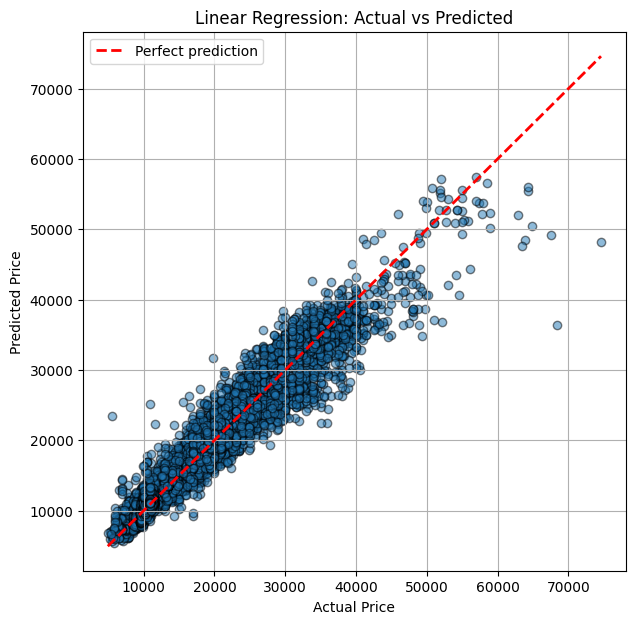

In [14]:
# Predictions on the test set
#y_pred = rfr.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y, y_pred_all, alpha=0.5, edgecolors='black', linewidths=1)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 
         color='red', linestyle='--', linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()